In [15]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Инструменты для подготовки данных и оценки
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Модели
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

# Продвинутые инструменты
import optuna
import shap

# Настройки отображения
sns.set_theme(style="whitegrid")
shap.initjs() # Инициализация JS для интерактивных графиков SHAP
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Загружаем очищенные данные
data_path = '../data/telco_cleaned.csv'
df = pd.read_csv(data_path)

# Отделяем целевую переменную от признаков
X = df.drop('Churn', axis=1)
y = df['Churn']

# One-Hot Encoding для категориальных признаков
X_encoded = pd.get_dummies(X, drop_first=True)

# Разделение на обучающую и тестовую выборки (80/20) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабирование числовых признаков 
# (Сохраняем формат DataFrame, чтобы не потерять названия колонок для SHAP)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f"Обучающая выборка: {X_train_scaled.shape}")
print(f"Тестовая выборка: {X_test_scaled.shape}")

Обучающая выборка: (5625, 30)
Тестовая выборка: (1407, 30)


In [17]:
# Инициализация и обучение базовой модели
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

# Предсказания
base_preds = baseline_model.predict(X_test_scaled)
base_probs = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Расчет метрик
base_roc_auc = roc_auc_score(y_test, base_probs)
base_f1 = f1_score(y_test, base_preds)

print("=== Результаты Baseline (Logistic Regression) ===")
print(f"ROC-AUC: {base_roc_auc:.4f}")
print(f"F1-Score: {base_f1:.4f}")

=== Результаты Baseline (Logistic Regression) ===
ROC-AUC: 0.8361
F1-Score: 0.6088


In [18]:
# Отключаем внутреннее логирование Optuna, чтобы не засорять вывод
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Задаем пространство поиска для CatBoost
    param = {
        "iterations": trial.suggest_int("iterations", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 10.0, log=True),
        "task_type": "GPU", # Оставляем GPU!
        "random_seed": 42,
        "verbose": False
    }

    # Обучаем модель с текущими параметрами
    model = CatBoostClassifier(**param)
    model.fit(X_train_scaled, y_train)
    
    # Оцениваем по F1-score (фокус на удержание уходящих клиентов)
    preds = model.predict(X_test_scaled)
    return f1_score(y_test, preds)

print("Запускаем байесовскую оптимизацию через Optuna (20 попыток)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20) 

print(f"Успешно! Лучший F1-Score на валидации: {study.best_value:.4f}")
print("Лучшие найденные параметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Запускаем байесовскую оптимизацию через Optuna (20 попыток)...
Успешно! Лучший F1-Score на валидации: 0.5828
Лучшие найденные параметры:
  iterations: 811
  learning_rate: 0.010063051773144581
  depth: 7
  l2_leaf_reg: 0.7042814936018564


In [19]:
# Берем лучшие параметры из Optuna и добавляем системные настройки
best_params = study.best_params
best_params["task_type"] = "GPU"
best_params["random_seed"] = 42
best_params["verbose"] = 100 # Покажет процесс обучения

# Обучаем финальную модель
final_model = CatBoostClassifier(**best_params)
final_model.fit(X_train_scaled, y_train)

# Предсказания
cb_preds = final_model.predict(X_test_scaled)
cb_probs = final_model.predict_proba(X_test_scaled)[:, 1]

# Расчет метрик
cb_roc_auc = roc_auc_score(y_test, cb_probs)
cb_f1 = f1_score(y_test, cb_preds)

print("\n=== Результаты финальной модели CatBoost (Optuna + GPU) ===")
print(f"ROC-AUC: {cb_roc_auc:.4f}")
print(f"F1-Score: {cb_f1:.4f}")

0:	learn: 0.6860902	total: 70.4ms	remaining: 57s
100:	learn: 0.4379433	total: 4s	remaining: 28.1s
200:	learn: 0.4054672	total: 7.75s	remaining: 23.5s
300:	learn: 0.3948215	total: 11.6s	remaining: 19.6s
400:	learn: 0.3892420	total: 14.7s	remaining: 15s
500:	learn: 0.3857564	total: 17.6s	remaining: 10.9s
600:	learn: 0.3830760	total: 20.4s	remaining: 7.14s
700:	learn: 0.3807220	total: 23.3s	remaining: 3.66s
800:	learn: 0.3785634	total: 26.3s	remaining: 328ms
810:	learn: 0.3784944	total: 26.5s	remaining: 0us

=== Результаты финальной модели CatBoost (Optuna + GPU) ===
ROC-AUC: 0.8416
F1-Score: 0.5828


In [20]:
results = pd.DataFrame({
    'Модель / конфигурация': ['Baseline (LogReg)', 'CatBoost + Optuna'],
    'Описание': ['Логистическая регрессия, стандартизация', 'Градиентный бустинг (GPU), тюнинг 20 итераций'],
    'ROC-AUC': [round(base_roc_auc, 4), round(cb_roc_auc, 4)],
    'F1-Score': [round(base_f1, 4), round(cb_f1, 4)],
    'Комментарий': ['Базовая интерпретируемая модель', 'Финальная модель с лучшей предсказательной силой']
})

display(results)

,Модель / конфигурация,Описание,ROC-AUC,F1-Score,Комментарий
0,Baseline (LogReg),"Логистическая регрессия, стандартизация",0.8361,0.6088,Базовая интерпретируемая модель
1,CatBoost + Optuna,"Градиентный бустинг (GPU), тюнинг 20 итераций",0.8416,0.5828,Финальная модель с лучшей предсказательной силой


График 1: Глобальная важность признаков


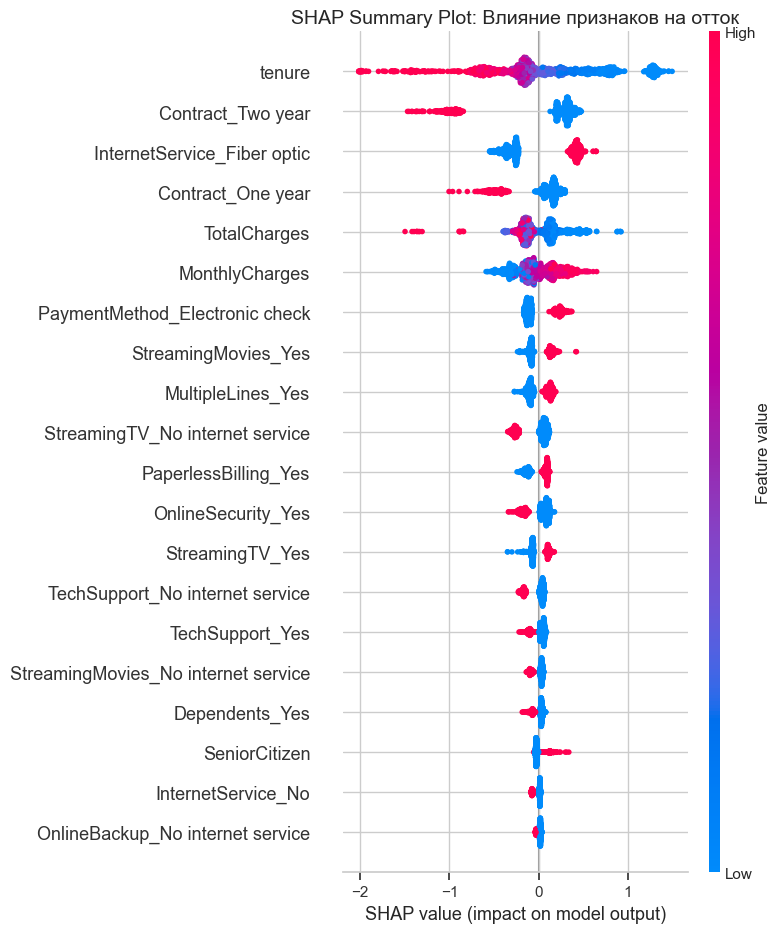


График 2: Разбор клиента с максимальной вероятностью оттока (индекс 1149)
Вероятность оттока: 92.31%


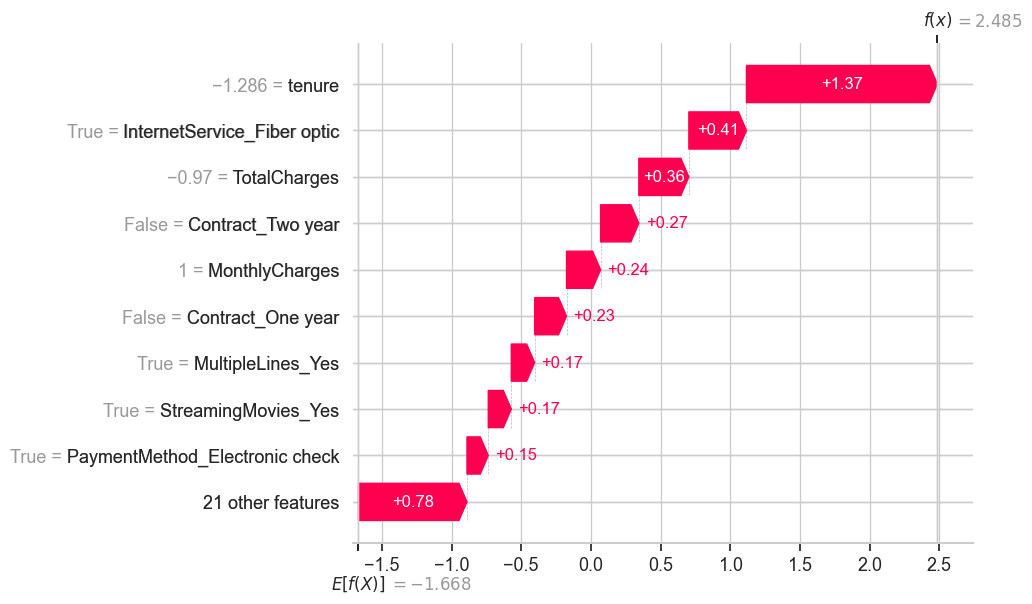

In [21]:
# Создаем SHAP explainer для CatBoost
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)

# 1. Summary Plot (Влияние всех признаков глобально)
print("График 1: Глобальная важность признаков")
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title('SHAP Summary Plot: Влияние признаков на отток', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Объяснение одного конкретного прогноза (Возьмем клиента, который скорее всего уйдет)
high_risk_index = np.argmax(cb_probs) 
print(f"\nГрафик 2: Разбор клиента с максимальной вероятностью оттока (индекс {high_risk_index})")
print(f"Вероятность оттока: {cb_probs[high_risk_index]:.2%}")

# Строим Waterfall plot
shap.waterfall_plot(shap.Explanation(values=shap_values[high_risk_index], 
                                     base_values=explainer.expected_value, 
                                     data=X_test_scaled.iloc[high_risk_index],  
                                     feature_names=X_test_scaled.columns))

In [22]:
os.makedirs('../artifacts', exist_ok=True)

# 1. Сохраняем модель
final_model.save_model('../artifacts/catboost_churn_model.cbm')

# 2. Сохраняем Scaler 
with open('../artifacts/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Сохраняем названия и порядок колонок
with open('../artifacts/features.pkl', 'wb') as f:
    pickle.dump(list(X_encoded.columns), f)

print("Все артефакты для сервиса успешно сохранены в папку 'artifacts/'.")

Все артефакты для сервиса успешно сохранены в папку 'artifacts/'.
